In [1]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "paths.json").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing config/paths.json")

REPO_ROOT = find_repo_root()
UTILS_DIR = REPO_ROOT / "code" / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

from project_paths import ensure_project_dirs, load_project_paths

PATHS = ensure_project_dirs(load_project_paths(REPO_ROOT))

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import starbars
import pingouin as pg


In [2]:

bids_root = PATHS["bids_root"]
subjects = ['sub-HDP01', 'sub-HDP02', 'sub-HDP03', 'sub-HDP04', 'sub-HDP06', 'sub-HDP08', 'sub-HDP09', 'sub-HDP10', 'sub-HDP12', 'sub-HDP13', 'sub-HDP15', 'sub-HDP17', 'sub-HDP18', 'sub-HDP19']
sessions = ["ses-01", "ses-02"]
output_dir = PATHS["surface_figures_root"]
(output_dir / "CMRglc").mkdir(parents=True, exist_ok=True)
(output_dir / "Figures").mkdir(parents=True, exist_ok=True)
participants_file = PATHS["participants_file"]
participants_data = pd.read_csv(participants_file, sep="\t")

results_kinfitr = pd.read_csv(PATHS["kinfitr_output_root"] / '02_Outcomes' / '03_model_outcomes' / '2TCM_irreversible.tsv', sep="\t")
results_kinfitr['condition'] = results_kinfitr['condition'].replace({'Verum': 'DMT + har'})

results_kinfitr_patlak = pd.read_csv(PATHS["kinfitr_output_root"] / '02_Outcomes' / '03_model_outcomes' / 'Patlak_outcomes.tsv', sep="\t")
results_kinfitr_patlak['condition'] = results_kinfitr_patlak['condition'].replace({'Verum': 'DMT + har'})


### Plot whole brain CMRglc differences

/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38920/3150341496.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([label.get_text() for label in ax.get_yticklabels()], weight='bold', fontsize=12)


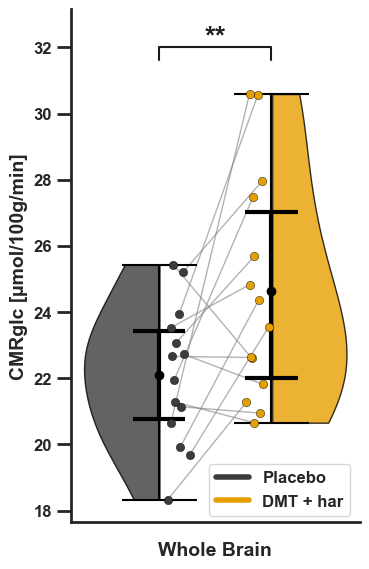

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib

sns.set_theme(style="ticks", rc={"figure.figsize": (20, 10)}, font_scale=1.4)
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

# Preprocess DataFrame
df_plot = results_kinfitr.copy()
df_par = df_plot[df_plot['Region'] == 'whole_brain']

# Plotting setup
fig, ax = plt.subplots(figsize=(4, 6))
offset = 0.15
jitter_strength = 0.015
conditions = ['Placebo', 'DMT + har']
colors = {'Placebo': '#3C3C3C', 'DMT + har': '#E69F00'}

# Violin plots
for side, condition in zip(['left', 'right'], conditions):
    df_cond = df_par[df_par['condition'] == condition]
    values = df_cond['CMRglc_tcm'].values

    parts = ax.violinplot(
        dataset=values,
        positions=[0 - offset if condition == 'Placebo' else 0 + offset],
        showextrema=True,
        widths=0.4
    )

    for pc in parts['bodies']:
        pc.set_facecolor(colors[condition])
        pc.set_edgecolor('black')
        pc.set_alpha(0.8)
        path = pc.get_paths()[0]
        vertices = path.vertices
        mean_x = np.mean(vertices[:, 0])

        if side == 'left':
            vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, mean_x)
            ax.plot(0 - offset, np.mean(values), 'o', color='black', markersize=6)
            q1, q3 = np.percentile(values, [25, 75])
            ax.vlines(0 - offset, q1, q3, color='black', linestyle='-', lw=3)
            ax.hlines(q1, 0 - offset - 0.07, 0 - offset + 0.07, color='black', lw=3)
            ax.hlines(q3, 0 - offset - 0.07, 0 - offset + 0.07, color='black', lw=3)
        else:
            vertices[:, 0] = np.clip(vertices[:, 0], mean_x, np.inf)
            ax.plot(0 + offset, np.mean(values), 'o', color='black', markersize=6)
            q1, q3 = np.percentile(values, [25, 75])
            ax.vlines(0 + offset, q1, q3, color='black', linestyle='-', lw=3)
            ax.hlines(q1, 0 + offset - 0.07, 0 + offset + 0.07, color='black', lw=3)
            ax.hlines(q3, 0 + offset - 0.07, 0 + offset + 0.07, color='black', lw=3)

    parts['cbars'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cmaxes'].set_color('black')

# Connect paired participant points
subjects = df_par['sub'].unique()
for subj in subjects:
    subj_data = df_par[df_par['sub'] == subj]
    if len(subj_data) == 2:
        y_placebo = subj_data[subj_data['condition'] == 'Placebo']['CMRglc_tcm'].values[0]
        y_dmt = subj_data[subj_data['condition'] == 'DMT + har']['CMRglc_tcm'].values[0]

        jitter = np.random.normal(0, jitter_strength)
        x_placebo = 0 - offset * 0.7 + jitter
        x_dmt = 0 + offset * 0.7 + jitter

        ax.plot([x_placebo, x_dmt], [y_placebo, y_dmt], color='gray', alpha=0.6, lw=1, zorder=1)
        ax.scatter(x_placebo, y_placebo, color=colors['Placebo'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)
        ax.scatter(x_dmt, y_dmt, color=colors['DMT + har'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)

# Formatting
sns.despine()
ax.set_xticks([0])
ax.set_xticklabels(['Whole Brain'], fontsize=14, weight='bold')
ax.set_yticklabels([label.get_text() for label in ax.get_yticklabels()], weight='bold', fontsize=12)
ax.set_ylabel('CMRglc [µmol/100g/min]', fontsize=14, weight='bold')
ax.set_xlabel(None)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='y', which='both', width=2, length=10)
ax.tick_params(axis='x', which='both', width=2, color='white', length=10)

# Custom legend
handles = [matplotlib.lines.Line2D([0], [0], color=color, lw=4) for color in colors.values()]
labels = list(colors.keys())
ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.45, 0.13), fontsize=12)

plt.tight_layout()

# Statistical annotations
pval = 0.006409 ## from kinfitr script
#annotations = [(('whole_brain', 'Placebo'), ('whole_brain','DMT + har'), pval)]
annotations = [(-offset, offset, pval)]
starbars.draw_annotation(annotations, fontsize=20, text_distance=0.02, top_margin=0)#, bar_margin=0)
#draw_flat_annotations(ax, annotations, top_margin=0.01, text_distance=0.005, fontsize=26)

plt.savefig(output_dir / "CMRglc" / "CMRglc_whole_brain_violin_connected_two_tissue.png", dpi=600, bbox_inches='tight')

## Create K1, k2, k3 plots

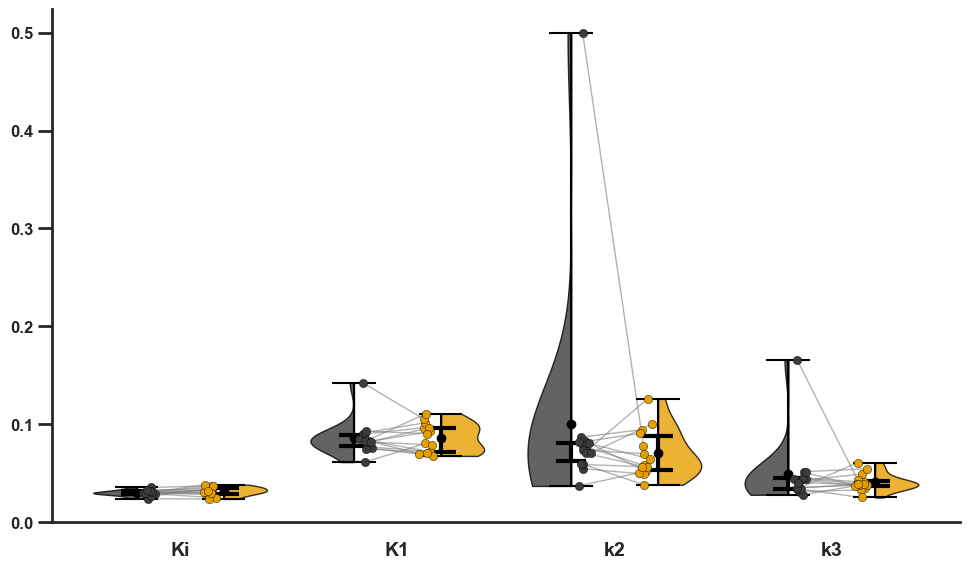

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib

sns.set_theme(style="ticks", rc={"figure.figsize": (20, 10)}, font_scale=1.4)
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

df_par = df_plot[df_plot['Region'] == 'whole_brain']


# Settings
offset = 0.2
jitter_strength = 0.015
parameters = ["Ki", "K1", "k2", "k3"]
subjects = df_par['sub'].unique()

fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over parameters
for i, par in enumerate(parameters):

    # Violin plots (no change here — violins stay at offset)
    for side, condition in zip(['left', 'right'], conditions):
        df_cond = df_par[df_par['condition'] == condition]
        values = df_cond[par].values

        parts = ax.violinplot(
            dataset=values,
            positions=[i - offset if condition == 'Placebo' else i + offset],
            showextrema=True,
            widths=0.4
        )

        for pc in parts['bodies']:
            pc.set_facecolor(colors[condition])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)
            path = pc.get_paths()[0]
            vertices = path.vertices
            mean_x = np.mean(vertices[:, 0])

            if side == 'left':
                vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, mean_x)
                ax.plot(i-offset, np.mean(values), 'o', color='black', markersize=6,)  # Mean marker
                # Add vertical lines for quantiles to resemble a boxplot on the right
                q1, q3 = np.percentile(values, [25, 75])
                ax.vlines(i-offset, q1, q3, color='black', linestyle='-', lw=3)  # Interquartile range
                ax.hlines(q1, i-offset-0.07, i-offset+0.07, color='black', linestyle='-', lw=3)  # Lower quantile line
                ax.hlines(q3, i-offset-0.07, i-offset+0.07, color='black', linestyle='-', lw=3)  # Upper quantile line
            else:
                vertices[:, 0] = np.clip(vertices[:, 0], mean_x, np.inf)
                ax.plot(i+offset, np.mean(values), 'o', color='black', markersize=6,)  # Mean marker
                # Add vertical lines for quantiles to resemble a boxplot on the right
                q1, q3 = np.percentile(values, [25, 75])
                ax.vlines(i+offset, q1, q3, color='black', linestyle='-', lw=3)  # Interquartile range
                ax.hlines(q1, i+offset-0.07, i+offset+0.07, color='black', linestyle='-', lw=3)  # Lower quantile line
                ax.hlines(q3, i+offset-0.07, i+offset+0.07, color='black', linestyle='-', lw=3)  # Upper quantile line


        # Customize the appearance of the violin plot components
        parts['cbars'].set_color('black')  # Central line
        parts['cmins'].set_color('black')  # Bottom of the violin
        parts['cmaxes'].set_color('black')  # Top of the violin

    # Individual points — changed only x values
    for subj in subjects:
        subj_data = df_par[df_par['sub'] == subj]
        if len(subj_data) == 2:
            y_placebo = subj_data[subj_data['condition'] == 'Placebo'][par].values[0]
            y_dmt = subj_data[subj_data['condition'] == 'DMT + har'][par].values[0]

            jitter = np.random.normal(0, jitter_strength)
            x_placebo = i - offset*0.7 + jitter                 
            x_dmt = i + offset*0.7 + jitter                   

            ax.plot([x_placebo, x_dmt], [y_placebo, y_dmt], color='gray', alpha=0.6, lw=1, zorder=1)
            ax.scatter(x_placebo, y_placebo, color=colors['Placebo'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)
            ax.scatter(x_dmt, y_dmt, color=colors['DMT + har'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)

# Formatting
sns.despine()
ax.set_xticks(range(len(parameters)))
ax.set_xticklabels(parameters, fontsize=14, weight='bold')
ax.set_ylabel('', fontsize=14, weight='bold')
ax.set_xlabel(None)
#ax.set_ylim(10, 28)
ax.tick_params(axis='y', which='major', labelsize=12)#, width=2, length=5)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='y', which='both', width=2, length=10)
ax.tick_params(axis='x', which='both', width=2, color='white', length=10)

# Custom legend for conditions
handles = [matplotlib.lines.Line2D([0], [0], color=color, lw=4) for color in colors.values()]
labels = list(colors.keys())
#ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.75, 0.95), fontsize=20)

# Statistical annotations
#annotations = []
#for i, par in enumerate(parameters):
#    x1 = i - offset  # DMT side
#    x2 = i + offset  # Placebo side
#    pval = yeo_p_value_mean[i]

#    annotations.append(((x1), (x2), pval))
#starbars.draw_annotation(annotations, fontsize=30, text_distance=0.0, top_margin=0.05, bar_margin=0)
#draw_flat_annotations(ax, annotations, top_margin=0.01, text_distance=0.005, fontsize=26)
plt.tight_layout()
plt.savefig(output_dir / "CMRglc" / "CMRglc_two_tissue_model_parameters_violin.png", dpi=600, bbox_inches='tight')
# plt.close()

Patlak vs Two-tissue model CMRglc: r = 0.9481, p = 1.86e-14


/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38920/1163170609.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([label.get_text() for label in plt.gca().get_xticklabels()], weight='bold')
/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38920/1163170609.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([label.get_text() for label in plt.gca().get_yticklabels()], weight='bold')


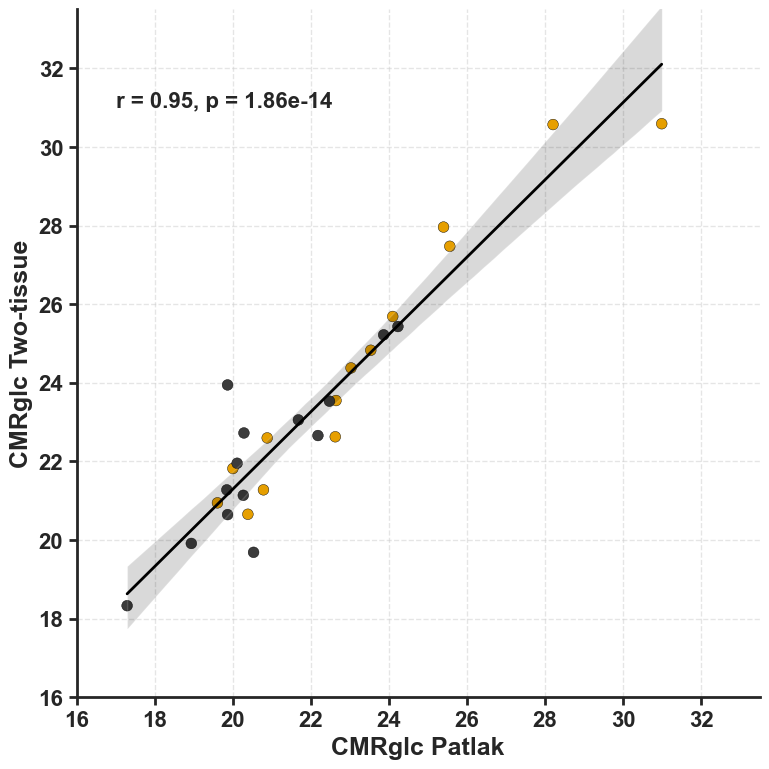

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd

# Merge and filter to whole brain
merged_df = pd.merge(
    results_kinfitr_patlak,
    results_kinfitr,
    on=['sub', 'condition', 'Region'],
)

merged_df = merged_df[merged_df['Region'] == 'whole_brain']

# Extract values
cmrglc_tcm = merged_df["CMRglc_tcm"]
cmrglc_patlak = merged_df["CMRglc"]
conditions = merged_df["condition"]

# Correlation
corr, p_value = pearsonr(cmrglc_patlak, cmrglc_tcm)
print(f"Patlak vs Two-tissue model CMRglc: r = {corr:.4f}, p = {p_value:.2e}")

# Set colors
palette = {'Placebo': '#3C3C3C', 'DMT + har': '#E69F00'}

# Plot
plt.figure(figsize=(8, 8))

# Scatter with manual color
sns.scatterplot(
    x=cmrglc_patlak,
    y=cmrglc_tcm,
    hue=conditions,
    palette=palette,
    s=60,
    alpha=1,
    edgecolor='black',
    linewidth=0.3,
    legend=False
)

# Regression line (no scatter)
sns.regplot(
    x=cmrglc_patlak,
    y=cmrglc_tcm,
    scatter=False,
    color='black',
    line_kws={'lw': 2},
    ci=95
)

# Style
sns.despine()
plt.gca().spines['left'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)

plt.xlabel("CMRglc Patlak", fontsize=18, weight='bold')
plt.ylabel("CMRglc Two-tissue", fontsize=18, weight='bold')
#plt.legend([f'r = {corr:.2f}, p = {p_value:.2e}'], loc='upper left', prop={'weight': 'bold', 'size': 16})
plt.text(
    17, 31,  # adjust based on your plot limits
    f'r = {corr:.2f}, p = {p_value:.2e}',
    fontsize=16,
    weight='bold'
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16, width=2)
plt.ylim(16, 33.5)
plt.xlim(16, 33.5)
#plt.xticks(])
plt.gca().set_xticklabels([label.get_text() for label in plt.gca().get_xticklabels()], weight='bold')
plt.gca().set_yticklabels([label.get_text() for label in plt.gca().get_yticklabels()], weight='bold')

plt.tight_layout()
plt.savefig(output_dir / "CMRglc" / "Correlations_patlak_two_tissue_model_cmrglc.png", dpi=600, bbox_inches='tight')
plt.show()

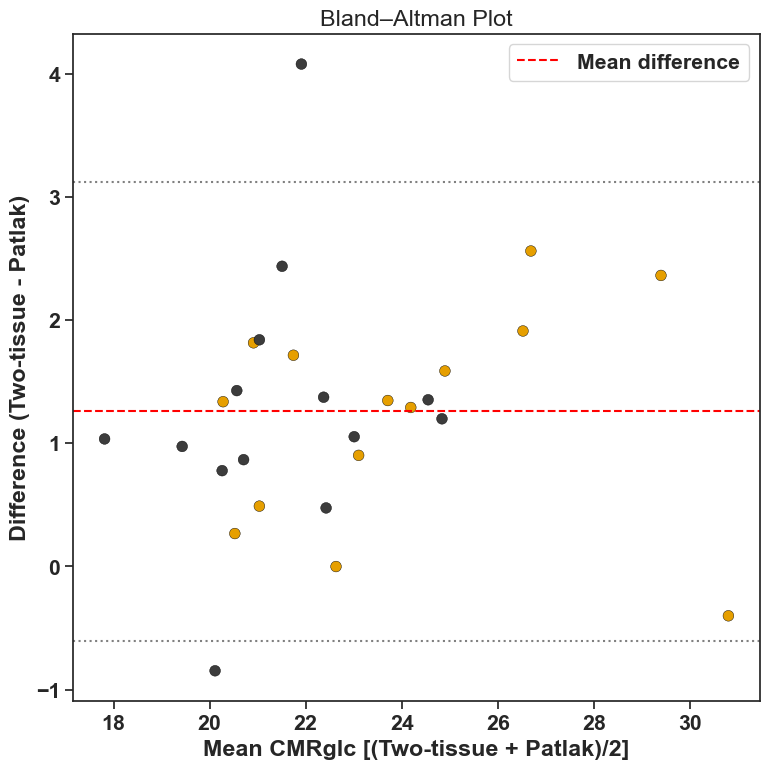

In [6]:
import matplotlib.pyplot as plt
import numpy as np

mean_vals = (cmrglc_patlak + cmrglc_tcm) / 2
diff_vals = cmrglc_tcm - cmrglc_patlak  # 2T model minus Patlak
mean_diff = np.mean(diff_vals)
std_diff = np.std(diff_vals)

point_colors = conditions.map(palette)


plt.figure(figsize=(8, 8))
plt.scatter(mean_vals, diff_vals, c=point_colors, edgecolor='black', s=60, linewidth=0.3)
plt.axhline(mean_diff, color='red', linestyle='--', label='Mean difference')
plt.axhline(mean_diff + 1.96*std_diff, color='gray', linestyle=':')
plt.axhline(mean_diff - 1.96*std_diff, color='gray', linestyle=':')
plt.xlabel('Mean CMRglc [(Two-tissue + Patlak)/2]')
plt.ylabel('Difference (Two-tissue - Patlak)')
plt.title('Bland–Altman Plot')
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "CMRglc" / "Bland_Altman_plot_patlak_two_tissue_model_cmrglc.png", dpi=600, bbox_inches='tight')
plt.show()

## Calculate Intraclass Correlation Coefficient (ICC)

In [7]:
# Melt wide to long
df_long = pd.melt(
    merged_df,
    id_vars=['sub', 'condition', 'Region'],
    value_vars=['CMRglc', 'CMRglc_tcm'],
    var_name='model',
    value_name='cmrglc'
)

# Rename model values
df_long['model'] = df_long['model'].replace({
    'CMRglc': 'Patlak',
    'CMRglc_tcm': 'Two-tissue'
})


import pingouin as pg

icc_results = pg.intraclass_corr(
    data=df_long[df_long['Region'] == 'whole_brain'],  # Filter for whole brain region
    targets='sub',        # subject ID
    raters='model',       # "CMRglc" vs. "CMRglc_tcm"
    ratings='cmrglc'      # actual CMRglc value
)

print(icc_results)


    Type              Description       ICC          F  df1  df2      pval  \
0   ICC1   Single raters absolute  0.756132   7.201165   13   14  0.000384   
1   ICC2     Single random raters  0.774597  21.942657   13   13  0.000001   
2   ICC3      Single fixed raters  0.912826  21.942657   13   13  0.000001   
3  ICC1k  Average raters absolute  0.861134   7.201165   13   14  0.000384   
4  ICC2k    Average random raters  0.872983  21.942657   13   13  0.000001   
5  ICC3k     Average fixed raters  0.954427  21.942657   13   13  0.000001   

           CI95%  
0   [0.41, 0.91]  
1  [-0.04, 0.94]  
2   [0.75, 0.97]  
3   [0.58, 0.95]  
4  [-0.08, 0.97]  
5   [0.86, 0.99]  


## Create composite plot

/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38920/1477656665.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


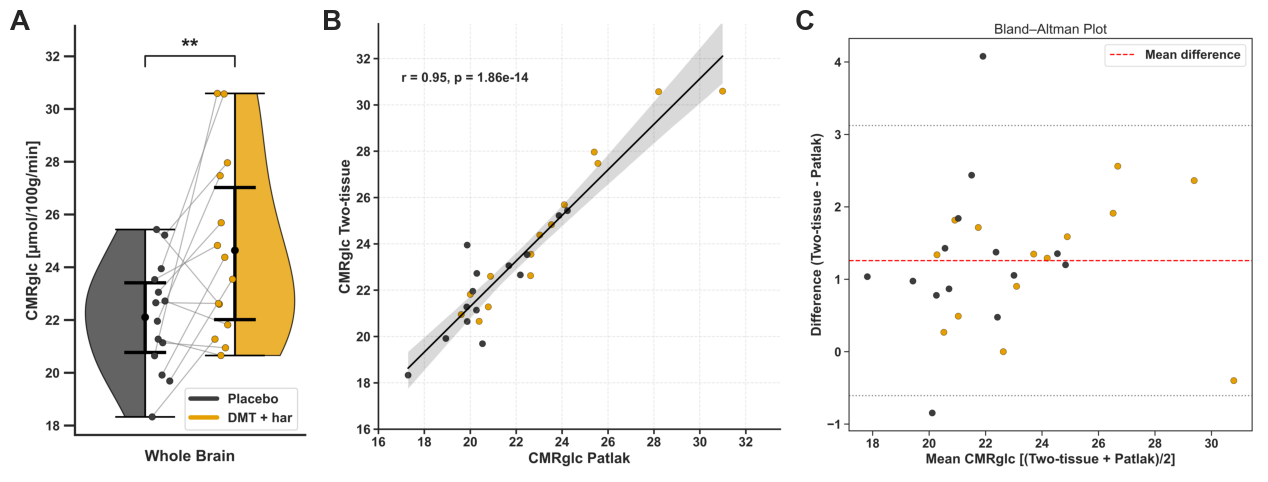

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg

# Load images
img_a = mpimg.imread(output_dir / "CMRglc" / "CMRglc_whole_brain_violin_connected_two_tissue.png")
img_c = mpimg.imread(output_dir / "CMRglc" / "Correlations_patlak_two_tissue_model_cmrglc.png")
img_d = mpimg.imread(output_dir / "CMRglc" / "Bland_Altman_plot_patlak_two_tissue_model_cmrglc.png")

# Create figure and grid layout
fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.65, 1, 1], wspace=0.05, hspace=0.0)

ax_a = plt.subplot(gs[0])
ax_a.imshow(img_a)
ax_a.axis('off')
ax_a.text(0.04, 1.02, "A", transform=ax_a.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')

ax_c = plt.subplot(gs[1])
ax_c.imshow(img_c)
ax_c.axis('off')
ax_c.text(0.02, 1.02, "B", transform=ax_c.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')

ax_d = plt.subplot(gs[2])
ax_d.imshow(img_d)
ax_d.axis('off')
ax_d.text(0.02, 1.02, "C", transform=ax_d.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')

# Save and show the composite figure
plt.tight_layout()
plt.savefig(output_dir / "Figures" / "CMRglc_whole_brain_two_tissue_composite.png", dpi=600, bbox_inches='tight')
plt.show()